In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score
from sklearn.ensemble import IsolationForest
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline

df = pd.read_csv('AmesHousing.csv')

cat_cols = ['Alley', 'Pool QC', 'Fence', 'Misc Feature', 'Fireplace Qu']
num_cols = ['Bsmt Full Bath', 'Garage Area', 'Garage Cars', 'Total Bsmt SF']

for col in cat_cols:
    if col in df.columns:
        df[col] = df[col].fillna("None")
        
for col in num_cols:
    if col in df.columns:
        df[col] = df[col].fillna(0)

df['Lot Frontage'] = df.groupby('Neighborhood')['Lot Frontage'].transform(lambda x: x.fillna(x.median()))
df['Lot Frontage'] = df['Lot Frontage'].fillna(df['Lot Frontage'].median())

num_vars = df.select_dtypes(include=[np.number]).columns
cat_vars = df.select_dtypes(include=['object']).columns

df[num_vars] = df[num_vars].fillna(df[num_vars].median())
df[cat_vars] = df[cat_vars].apply(lambda x: x.fillna(x.mode()[0]))

df['Age'] = df['Yr Sold'] - df['Year Built']
df['Years_Since_Remodel'] = df['Yr Sold'] - df['Year Remod/Add']

c:\Users\livee\miniconda3\envs\torch_course\lib\site-packages\numpy\lib\_nanfunctions_impl.py:1215: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
c:\Users\livee\miniconda3\envs\torch_course\lib\site-packages\numpy\lib\_nanfunctions_impl.py:1215: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)


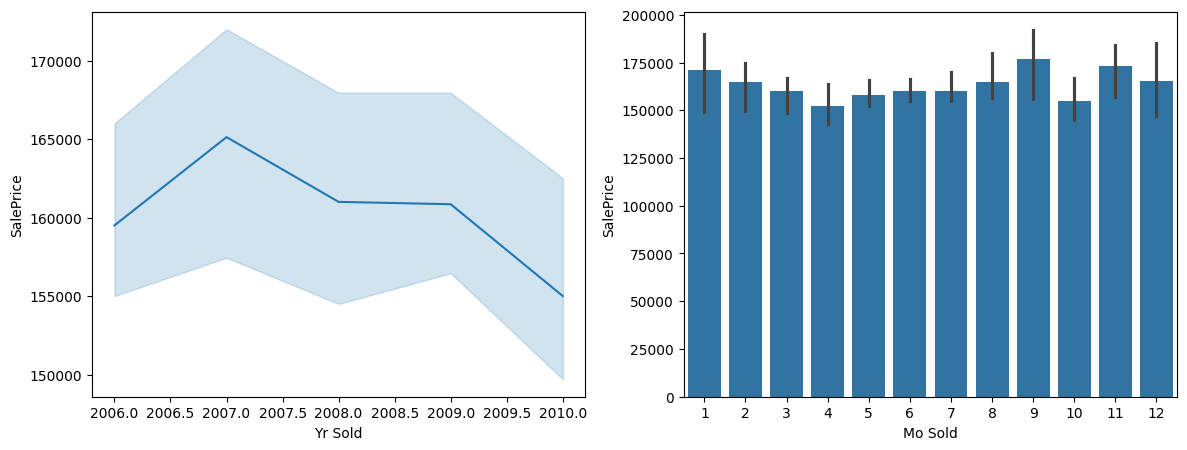

In [3]:
fig, ax = plt.subplots(1, 2, figsize=(14, 5))
sns.lineplot(data=df, x='Yr Sold', y='SalePrice', estimator=np.median, ax=ax[0])
sns.barplot(data=df, x='Mo Sold', y='SalePrice', estimator=np.median, ax=ax[1])
plt.show()

In [4]:
df_dummies = pd.get_dummies(df, drop_first=True)
X = df_dummies.drop(columns=['SalePrice'])
y = df_dummies['SalePrice']

X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.2, random_state=42)

pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('ridge', Ridge(alpha=10.0))
])

pipe.fit(X_tr, y_tr)
print(r2_score(y_te, pipe.predict(X_te)))

top_coefs = pd.Series(pipe.named_steps['ridge'].coef_, index=X.columns).abs().nlargest(10)
print(top_coefs.index.tolist())

0.8914275505343102
['Roof Matl_CompShg', 'Roof Matl_Tar&Grv', 'Misc Feature_Shed', 'Misc Feature_None', 'Roof Matl_WdShngl', 'Roof Matl_WdShake', 'Gr Liv Area', '2nd Flr SF', 'Kitchen Qual_TA', 'Misc Feature_Gar2']


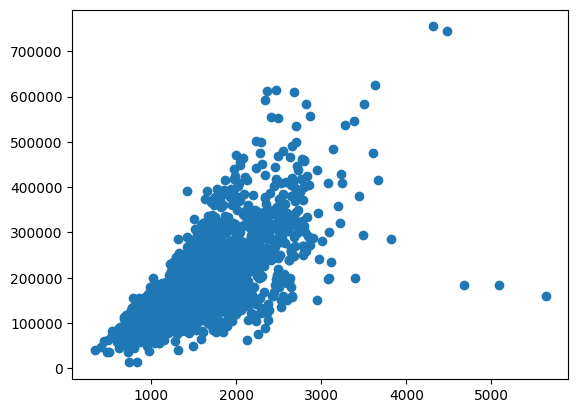

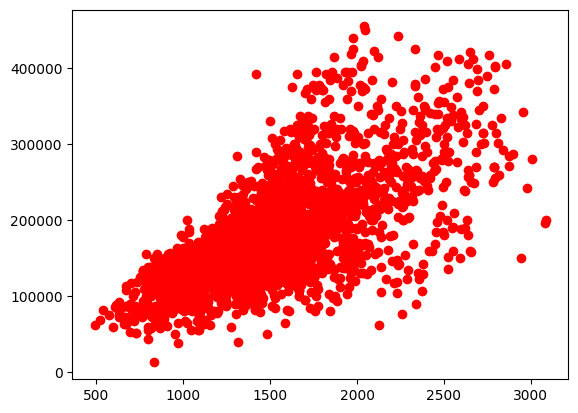

In [5]:
plt.scatter(df['Gr Liv Area'], df['SalePrice'])
plt.show()

iso_forest = IsolationForest(contamination=0.02, random_state=42)
inliers = iso_forest.fit_predict(df[['Gr Liv Area', 'SalePrice']]) == 1
logic_filter = ~((df['Gr Liv Area'] > 4000) & (df['SalePrice'] < 300000))

valid_idx = inliers & logic_filter
df_filtered = df_dummies[valid_idx]

plt.scatter(df_filtered['Gr Liv Area'], df_filtered['SalePrice'], c='red')
plt.show()

In [6]:
X_f = df_filtered.drop(columns=['SalePrice'])
y_f = df_filtered['SalePrice']

Xf_tr, Xf_te, yf_tr, yf_te = train_test_split(X_f, y_f, test_size=0.2, random_state=42)
pipe.fit(Xf_tr, yf_tr)
print(r2_score(yf_te, pipe.predict(Xf_te)))

0.9219994245495133


In [7]:
X_scaled = StandardScaler().fit_transform(X)
km = KMeans(n_clusters=5, random_state=42)
clusters = km.fit_predict(X_scaled)
print(pd.Series(clusters).value_counts().to_dict())

{4: 1111, 1: 603, 0: 504, 3: 471, 2: 241}


In [8]:
numeric_df = df.select_dtypes(include=np.number).drop(columns=['SalePrice'])
X_num_scaled = StandardScaler().fit_transform(numeric_df[valid_idx])

pca = PCA(n_components=25)
X_pca = pca.fit_transform(X_num_scaled)

Xp_tr, Xp_te, yp_tr, yp_te = train_test_split(X_pca, y_f, test_size=0.2, random_state=42)
ridge_pca = Ridge().fit(Xp_tr, yp_tr)
print(r2_score(yp_te, ridge_pca.predict(Xp_te)))

0.8560293046936907
